In [53]:
# Cell 1: 讀取第一階段輸出資料

from pathlib import Path

import geopandas as gpd
import osmnx as ox

TARGET_CRS = "EPSG:3826"

# ===== 路徑設定 =====
grid_path = Path("output/Taipei_grid_full_risk.geojson")
road_grid_path = Path("output/taipei_road_grid_segments.geojson")
shelter_path = Path("output/taipei_shelters_join_500m.geojson")
town_path = Path("data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp")
graph_path = Path("output/taipei_drive.graphml")

# ===== 檢查檔案是否存在 =====
required_paths = {
    "grid": grid_path,
    "road_grid_segments": road_grid_path,
    "shelters": shelter_path,
    "town": town_path,
    "road_graph": graph_path,
}

missing_paths = {
    name: path
    for name, path in required_paths.items()
    if not path.exists()
}

if missing_paths:
    raise FileNotFoundError(f"找不到檔案: {missing_paths}")

# ===== 1) 讀取風險 grid =====
g = gpd.read_file(grid_path).to_crs(TARGET_CRS)

# ===== 2) 讀取道路-grid 分段資料 =====
road_grid_segments = gpd.read_file(road_grid_path).to_crs(TARGET_CRS)

# ===== 3) 讀取避難所資料 =====
shelters = gpd.read_file(shelter_path).to_crs(TARGET_CRS)

# ===== 4) 讀取道路 graph，轉成 nodes / edges =====
G = ox.load_graphml(graph_path)
G = ox.project_graph(G, to_crs=TARGET_CRS)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

nodes_gdf = nodes_gdf.to_crs(TARGET_CRS)
edges_gdf = edges_gdf.to_crs(TARGET_CRS)

# ===== 5) 讀取台北市行政邊界 =====
town = gpd.read_file(town_path)
town.columns = [str(c).strip().strip("'").strip('"') for c in town.columns]

if "COUNTYCODE" in town.columns:
    taipei_boundary = town[
        town["COUNTYCODE"].astype(str).str.contains("63000", na=False)
    ].copy()
elif "COUNTYNAME" in town.columns:
    taipei_boundary = town[
        town["COUNTYNAME"].astype(str).str.contains("臺北市|台北市", na=False, regex=True)
    ].copy()
else:
    taipei_boundary = town.copy()

taipei_boundary = taipei_boundary.to_crs(TARGET_CRS)
boundary = taipei_boundary.dissolve()

# ===== 6) 基本檢查 =====
print("Grid:", len(g), g.crs)
print("Road-grid segments:", len(road_grid_segments), road_grid_segments.crs)
print("Shelters:", len(shelters), shelters.crs)
print("Road nodes:", len(nodes_gdf), nodes_gdf.crs)
print("Road edges:", len(edges_gdf), edges_gdf.crs)
print("Taipei boundary:", len(taipei_boundary), taipei_boundary.crs)

display(g.head())
display(road_grid_segments.head())
display(shelters.head())

Grid: 4585 EPSG:3826
Road-grid segments: 101018 EPSG:3826
Shelters: 311 EPSG:3826
Road nodes: 31582 EPSG:3826
Road edges: 74509 EPSG:3826
Taipei boundary: 12 EPSG:3826


,grid_id,mean_elevation,slope,river_ratio,dist_to_river_m,has_river,river_area_m2,grid_area_m2,flood_event_count,terrain_flood_risk,river_flood_risk,history_flood_risk,slope_risk,total_flood_risk,geometry
0,1,0.810000,0.028648,1.000000,0.0,True,560.609543,560.609543,0,3,3,0,0,6,"POLYGON ((296354.474 2777535.146, 296354.474 2..."
1,2,0.839252,0.046988,1.000000,0.0,True,42408.397157,42408.397157,0,3,3,0,0,6,"POLYGON ((296354.474 2777785.146, 296354.474 2..."
2,3,0.850146,0.069845,0.989481,0.0,True,58196.046081,58814.688398,0,3,3,0,0,6,"POLYGON ((296354.474 2778035.146, 296354.474 2..."
3,4,0.862900,0.105251,1.000000,0.0,True,39617.631903,39617.631903,0,3,3,0,0,6,"POLYGON ((296354.474 2778285.146, 296354.474 2..."
4,5,0.826875,0.171902,1.000000,0.0,True,8196.800432,8196.800432,0,3,3,0,0,6,"POLYGON ((296354.474 2778285.146, 296263.54 27..."


,road_grid_id,road_base_id,road_type,road_no_in_type,grid_id,segment_length_m,u,v,key,road_type_id,length,geometry
0,arterial_01_g2025,arterial_01,arterial,1,2025,136.835109,25423605,420039231,0,arterial,137.363787,"LINESTRING (305410.671 2770867.294, 305411.373..."
1,arterial_02_g2017,arterial_02,arterial,2,2017,33.029001,25423609,619301457,0,arterial,57.845791,"LINESTRING (305403.481 2769002.118, 305403.532..."
2,arterial_02_g2018,arterial_02,arterial,2,2018,24.593818,25423609,619301457,0,arterial,57.845791,"LINESTRING (305403.628 2769035.146, 305403.742..."
3,arterial_03_g1834,arterial_03,arterial,3,1834,24.580635,25423625,618955584,0,arterial,24.675584,"LINESTRING (304871.235 2770867.807, 304870.547..."
4,arterial_04_g859,arterial_04,arterial,4,859,48.622629,32615825,2575904203,0,arterial,48.559605,"LINESTRING (302076.556 2771821.502, 302065.193..."


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,risk_level,shelter_id,u,v,key,highway,road_type,length,dist_to_edge_m,geometry
0,4890,臺北市文山區,nan,文山區指南路3段38巷5-2號,121.5836,24.9764,指南國小,指南里,20,"水災,震災",...,高,0,4016149196,700244271,0,unclassified,bridge,76.419741,1.979584,POINT (308920.489 2763290.297)
1,4912,臺北市文山區,nan,文山區木新路3段312號,121.5562,24.9807,景美女中,樟林里、樟文里、樟樹里,300,"水災,震災",...,高,1,5257667796,7006341559,0,service,service,44.855742,5.567487,POINT (306152.164 2763754.967)
2,4916,臺北市文山區,nan,文山區木新路3段155巷7號,121.5610,24.9809,力行國小,樟新里、樟腳里、老泉里,30,"水災,震災",...,高,2,2142307016,2142307020,0,residential,residential,85.796761,12.973567,POINT (306636.675 2763779.115)
3,4929,臺北市文山區,nan,文山區辛亥路7段67號,121.5547,24.9834,實踐國中,樟林里,300,"水災,震災",...,高,3,2716430495,1225571023,0,service,service,80.422841,5.912413,POINT (305999.503 2764053.412)
4,4932,臺北市文山區,nan,文山區忠順街1段4號,121.5575,24.9836,實踐國小,樟文里、樟樹里,75,"水災,震災",...,高,4,1218518348,1218517708,0,tertiary,residential,128.468137,15.159715,POINT (306282.09 2764076.724)


## Rainfall kriging for Taipei grids


In [54]:
from pathlib import Path
import pandas as pd

rain_path = Path("data/rain_20240418.csv")

# 讀取雨量資料
rain = pd.read_csv(rain_path, encoding="utf-8-sig")

# 基本欄位清理
rain["CountyName"] = rain["CountyName"].astype(str).str.strip()
rain["DateTime"] = pd.to_datetime(rain["DateTime"], errors="coerce")

# 雨量與座標欄位轉數值
rain_cols = [
    "Past1hr",
    "Past10Min",
    "Past3hr",
    "Past6hr",
    "Past12hr",
    "Past24hr",
    "NOW",
    "Past2days",
    "Past3days",
]

num_cols = [
    "StationLatitude",
    "StationLongitude",
    "StationAltitude",
    *rain_cols,
]

for col in num_cols:
    rain[col] = pd.to_numeric(rain[col], errors="coerce")

# 只保留臺北市資料
rain_tp = rain[rain["CountyName"].isin(["臺北市", "台北市"])].copy()

print("臺北市雨量紀錄筆數:", len(rain_tp))
print("臺北市測站數:", rain_tp["StationId"].nunique())

display(rain_tp.head())

臺北市雨量紀錄筆數: 9698
臺北市測站數: 71


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,StationAltitude,DateTime,Past1hr,Past10Min,Past3hr,Past6hr,Past12hr,Past24hr,NOW,Past2days,Past3days
96,C0A770,科教館,臺北市,士林區,25.096355,121.51650,60.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160,CAA040,國三S016K,臺北市,南港區,25.033060,121.61580,71.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
166,CAA090,國三甲005K,臺北市,文山區,25.001940,121.59750,60.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
172,C1AI50,國三N016K,臺北市,南港區,25.034164,121.61967,64.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
173,G2AI50,台農院關渡站,臺北市,北投區,25.115750,121.49200,9.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5


In [55]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pykrige.ok import OrdinaryKriging

# ===== 參數設定 =====
target_time = pd.Timestamp("2024-04-18 09:00:00")

event_start = pd.Timestamp("2024-04-18 00:00:00")
event_end = pd.Timestamp("2024-04-19 00:00:00")

# 確保格式正確
rain_tp["DateTime"] = pd.to_datetime(rain_tp["DateTime"])

for col in ["Past3hr", "Past10Min", "StationLongitude", "StationLatitude"]:
    rain_tp[col] = pd.to_numeric(rain_tp[col], errors="coerce")

station_cols = [
    "StationId",
    "StationName",
    "CountyName",
    "TownName",
    "StationLatitude",
    "StationLongitude",
]

# ===== 1) 即時最近 3 小時雨量：直接用 Past3hr 欄位 =====
rain_past3hr_station = rain_tp[
    rain_tp["DateTime"] == target_time
].copy()

rain_past3hr_station = (
    rain_past3hr_station
    .dropna(subset=["Past3hr", "StationLatitude", "StationLongitude"])
    [station_cols + ["Past3hr"]]
    .rename(columns={"Past3hr": "rain_past3hr_mm"})
    .reset_index(drop=True)
)

# ===== 2) 整場事件累積雨量：用 Past10Min 加總 =====
rain_event = rain_tp[
    (rain_tp["DateTime"] >= event_start)
    & (rain_tp["DateTime"] < event_end)
].copy()

rain_event_station = (
    rain_event
    .dropna(subset=["Past10Min", "StationLatitude", "StationLongitude"])
    .groupby(station_cols, as_index=False)
    .agg(
        rain_event_total_mm=("Past10Min", "sum"),
        event_obs_count=("Past10Min", "count"),
    )
)

print("Past3hr 測站數:", len(rain_past3hr_station))
print("Past3hr 雨量範圍:",
      rain_past3hr_station["rain_past3hr_mm"].min(),
      "~",
      rain_past3hr_station["rain_past3hr_mm"].max())

print("事件累積測站數:", len(rain_event_station))
print("事件累積雨量範圍:",
      rain_event_station["rain_event_total_mm"].min(),
      "~",
      rain_event_station["rain_event_total_mm"].max())

display(rain_past3hr_station.sort_values("rain_past3hr_mm", ascending=False).head(10))
display(rain_event_station.sort_values("rain_event_total_mm", ascending=False).head(10))

Past3hr 測站數: 66
Past3hr 雨量範圍: 18.0 ~ 87.0
事件累積測站數: 71
事件累積雨量範圍: 0.0 ~ 82.0


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,rain_past3hr_mm
41,A1AD70,茶製場,臺北市,南港區,25.028387,121.663310,87.0
42,A1AC60,九如里,臺北市,南港區,25.032492,121.611600,83.5
34,A1AB40,玉成,臺北市,南港區,25.052193,121.582504,82.0
12,C0A9F0,內湖,臺北市,內湖區,25.079422,121.575450,81.5
62,C0AH70,松山,臺北市,松山區,25.048712,121.550430,81.5
13,C0AC70,信義,臺北市,信義區,25.037823,121.564600,81.0
1,C1AI50,國三N016K,臺北市,南港區,25.034164,121.619670,80.5
40,A1AC50,舊莊里,臺北市,南港區,25.033990,121.624700,79.5
3,CAA040,國三S016K,臺北市,南港區,25.033060,121.615800,77.5
29,A1AA80,市政中心,臺北市,信義區,25.038895,121.556404,76.5


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,rain_event_total_mm,event_obs_count
59,C0A9F0,內湖,臺北市,內湖區,25.079422,121.575450,82.0,143
64,C0AH70,松山,臺北市,松山區,25.048712,121.550430,82.0,143
61,C0AC70,信義,臺北市,信義區,25.037823,121.564600,81.5,143
67,C1AI50,國三N016K,臺北市,南港區,25.034164,121.619670,80.5,143
68,CAA040,國三S016K,臺北市,南港區,25.033060,121.615800,78.0,143
69,CAA090,國三甲005K,臺北市,文山區,25.001940,121.597500,77.0,143
3,466920,臺北,臺北市,中正區,25.037659,121.514854,76.0,143
5,A0A010,臺灣大學,臺北市,大安區,25.014278,121.539410,70.5,143
65,C0AI40,石牌,臺北市,北投區,25.115597,121.513170,70.0,143
58,C0A9C0,天母,臺北市,士林區,25.117495,121.537170,69.5,143


In [56]:
def kriging_to_grid(
    station_df,
    value_col,
    output_prefix,
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=15000,
    n_closest_points=16,
):
    station_gdf = gpd.GeoDataFrame(
        station_df,
        geometry=gpd.points_from_xy(
            station_df["StationLongitude"],
            station_df["StationLatitude"],
        ),
        crs="EPSG:4326",
    ).to_crs(TARGET_CRS)

    x = station_gdf.geometry.x.to_numpy()
    y = station_gdf.geometry.y.to_numpy()
    z = station_gdf[value_col].to_numpy()

    if sill is None:
        sill = np.var(z)

    if len(station_gdf) < 3:
        raise ValueError(f"{output_prefix}: 測站數少於 3，無法 kriging")

    if np.nanmax(z) == np.nanmin(z):
        pred = np.full(len(g), z[0])
        var = np.zeros(len(g))
    else:
        OK = OrdinaryKriging(
            x,
            y,
            z,
            variogram_model=variogram_model,
            variogram_parameters={
                "nugget": nugget,
                "sill": sill,
                "range": range_m,
            },
            coordinates_type="euclidean",
            verbose=False,
            enable_plotting=False,
        )

        grid_centroid = g.geometry.centroid
        grid_x = grid_centroid.x.to_numpy()
        grid_y = grid_centroid.y.to_numpy()

        pred, var = OK.execute(
            "points",
            grid_x,
            grid_y,
            n_closest_points=n_closest_points,
            backend="loop",
        )

        pred = np.asarray(pred, dtype=float)
        var = np.asarray(var, dtype=float)

    pred = np.clip(pred, 0, None)
    var = np.clip(var, 0, None)

    return pred, var


g_rain = g.copy()

past3_pred, past3_var = kriging_to_grid(
    rain_past3hr_station,
    "rain_past3hr_mm",
    "rain_past3hr",
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=10000,
    n_closest_points=12,
)

g_rain["rain_past3hr_mm"] = past3_pred
g_rain["rain_past3hr_var"] = past3_var
g_rain["rain_past3hr_std"] = np.sqrt(np.clip(past3_var, 0, None))

event_pred, event_var = kriging_to_grid(
    rain_event_station,
    "rain_event_total_mm",
    "rain_event_total",
    variogram_model="exponential",
    n_closest_points=12,
)

g_rain["rain_event_total_mm"] = event_pred
g_rain["rain_event_total_var"] = event_var
g_rain["rain_event_total_std"] = np.sqrt(np.clip(event_var, 0, None))

display(
    g_rain[
        [
            "grid_id",
            "rain_past3hr_mm",
            "rain_past3hr_std",
            "rain_event_total_mm",
            "rain_event_total_std",
        ]
    ].head()
)

,grid_id,rain_past3hr_mm,rain_past3hr_std,rain_event_total_mm,rain_event_total_std
0,1,64.390278,8.722108,46.469495,18.987233
1,2,63.916884,8.807834,49.280682,19.162595
2,3,63.364097,8.686970,52.579815,18.959928
3,4,62.782877,8.457284,55.766440,18.563032
4,5,62.299169,8.279067,57.926927,18.264978


## 視覺化

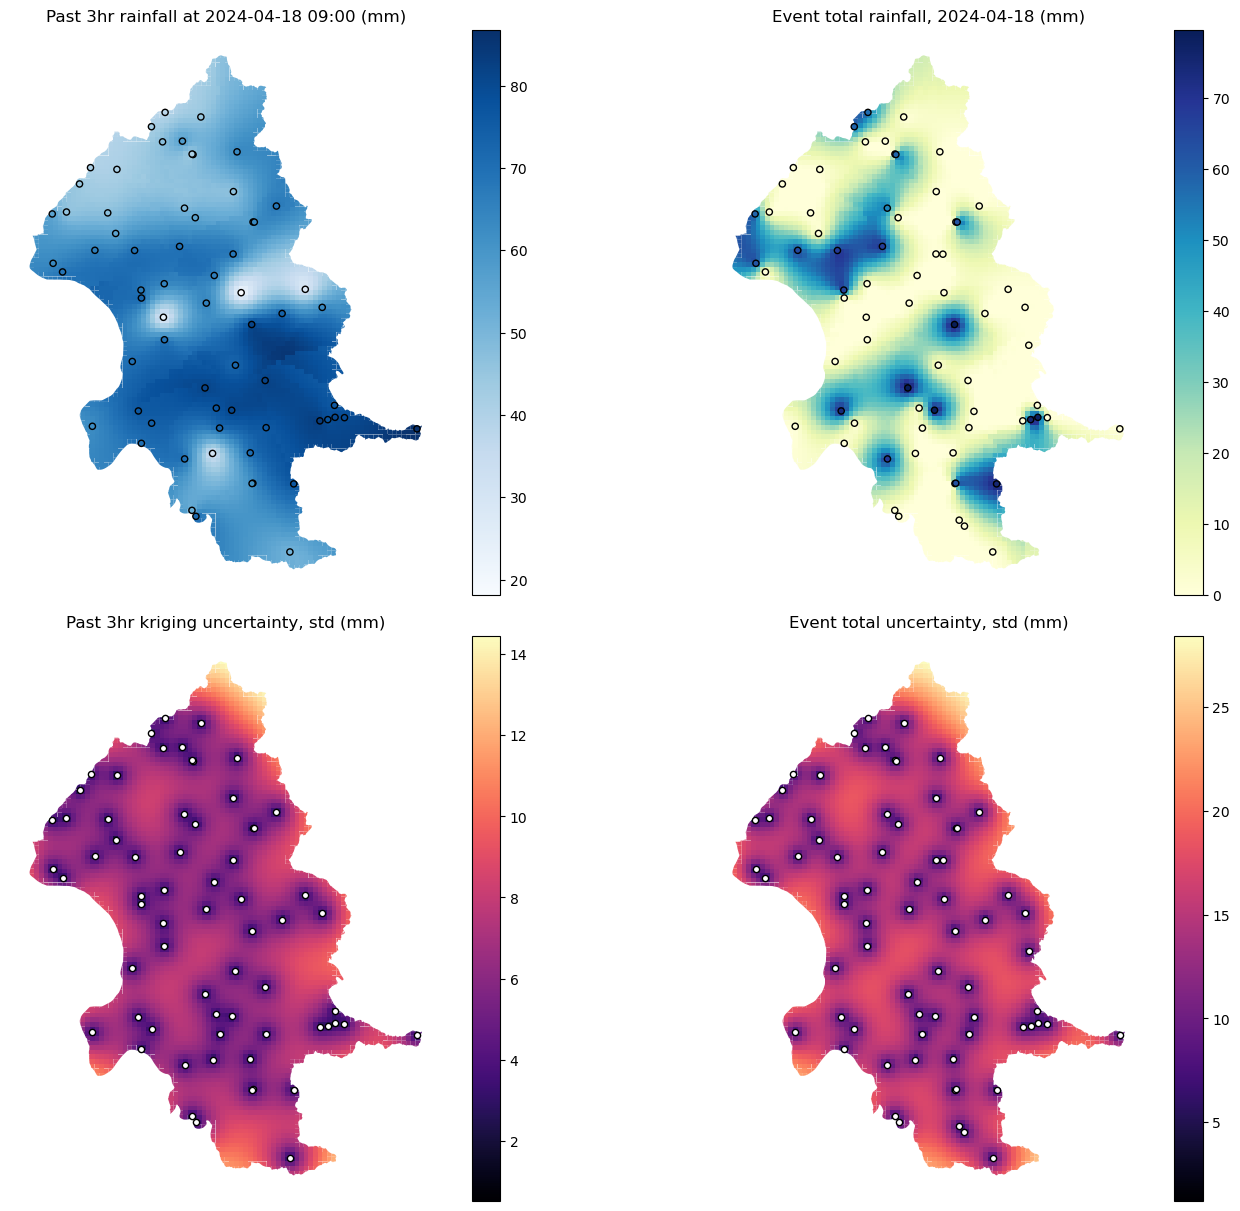

In [57]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 測站轉成 GDF，用來疊在圖上
rain_past3hr_gdf = gpd.GeoDataFrame(
    rain_past3hr_station,
    geometry=gpd.points_from_xy(
        rain_past3hr_station["StationLongitude"],
        rain_past3hr_station["StationLatitude"],
    ),
    crs="EPSG:4326",
).to_crs(TARGET_CRS)

rain_event_gdf = gpd.GeoDataFrame(
    rain_event_station,
    geometry=gpd.points_from_xy(
        rain_event_station["StationLongitude"],
        rain_event_station["StationLatitude"],
    ),
    crs="EPSG:4326",
).to_crs(TARGET_CRS)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# ===== 1) Past 3hr 雨量分布 =====
g_rain.plot(
    column="rain_past3hr_mm",
    ax=axes[0, 0],
    cmap="Blues",
    legend=True,
    linewidth=0,
)
rain_past3hr_gdf.plot(
    ax=axes[0, 0],
    column="rain_past3hr_mm",
    cmap="Blues",
    edgecolor="black",
    markersize=20,
)
axes[0, 0].set_title("Past 3hr rainfall (mm)")
axes[0, 0].set_axis_off()

# ===== 2) Event total 雨量分布 =====
g_rain.plot(
    column="rain_event_total_mm",
    ax=axes[0, 1],
    cmap="YlGnBu",
    legend=True,
    linewidth=0,
)
rain_event_gdf.plot(
    ax=axes[0, 1],
    column="rain_event_total_mm",
    cmap="YlGnBu",
    edgecolor="black",
    markersize=20,
)
axes[0, 1].set_title("Event total rainfall (mm)")
axes[0, 1].set_axis_off()

# ===== 3) Past 3hr 不確定度分布 =====
g_rain.plot(
    column="rain_past3hr_std",
    ax=axes[1, 0],
    cmap="magma",
    legend=True,
    linewidth=0,
)
rain_past3hr_gdf.plot(
    ax=axes[1, 0],
    color="white",
    edgecolor="black",
    markersize=20,
)
axes[1, 0].set_title("Past 3hr uncertainty, std (mm)")
axes[1, 0].set_axis_off()

# ===== 4) Event total 不確定度分布 =====
g_rain.plot(
    column="rain_event_total_std",
    ax=axes[1, 1],
    cmap="magma",
    legend=True,
    linewidth=0,
)
rain_event_gdf.plot(
    ax=axes[1, 1],
    color="white",
    edgecolor="black",
    markersize=20,
)
axes[0, 0].set_title("Past 3hr rainfall at 2024-04-18 09:00 (mm)")
axes[0, 1].set_title("Event total rainfall, 2024-04-18 (mm)")
axes[1, 0].set_title("Past 3hr kriging uncertainty, std (mm)")
axes[1, 1].set_title("Event total kriging uncertainty, std (mm)")
axes[1, 1].set_title("Event total uncertainty, std (mm)")
axes[1, 1].set_axis_off()

plt.show()

## 將完整雨量資料覆蓋到上

In [58]:
grid_rain = g.copy()

# ===== 同時保留兩種雨量資訊 =====
grid_rain["rain_past3hr_mm"] = g_rain["rain_past3hr_mm"]
grid_rain["rain_past3hr_std"] = g_rain["rain_past3hr_std"]

grid_rain["rain_event_total_mm"] = g_rain["rain_event_total_mm"]
grid_rain["rain_event_total_std"] = g_rain["rain_event_total_std"]

# 紀錄時間與事件範圍，之後報告比較清楚
grid_rain["past3hr_target_time"] = target_time
grid_rain["event_start"] = event_start
grid_rain["event_end"] = event_end

# 確認一個 grid_id 只有一筆
print("grid 數量:", len(grid_rain))
print("不重複 grid_id 數量:", grid_rain["grid_id"].nunique())

display(
    grid_rain[
        [
            "grid_id",
            "rain_past3hr_mm",
            "rain_past3hr_std",
            "rain_event_total_mm",
            "rain_event_total_std",
        ]
    ].head()
)

# ===== 輸出 =====
grid_rain.to_file(
    "output/Taipei_grid_with_rain_post.geojson",
    driver="GeoJSON",
    encoding="utf-8",
)

grid_rain.drop(columns="geometry").to_csv(
    "output/Taipei_grid_with_rain_post.csv",
    index=False,
    encoding="utf-8-sig",
)

grid 數量: 4585
不重複 grid_id 數量: 4585


,grid_id,rain_past3hr_mm,rain_past3hr_std,rain_event_total_mm,rain_event_total_std
0,1,64.390278,8.722108,46.469495,18.987233
1,2,63.916884,8.807834,49.280682,19.162595
2,3,63.364097,8.686970,52.579815,18.959928
3,4,62.782877,8.457284,55.766440,18.563032
4,5,62.299169,8.279067,57.926927,18.264978


## html製作 雨量分布

In [59]:
import os
import folium
import geopandas as gpd
import pandas as pd
import branca.colormap as cm

os.makedirs("output", exist_ok=True)

# ===== 0) 選擇 Post Map 要顯示哪一種雨量 =====
# 只能選一個，確保一個 grid 只有一個 rain_mm
rain_source_col = "rain_past3hr_mm"       # 可改成 "rain_event_total_mm"
rain_std_col = "rain_past3hr_std"         # 可改成 "rain_event_total_std"
rain_map_name = "Past 3hr Rainfall at 2024-04-18 09:00"

# ===== 1) Prepare data =====
map_grid = g_rain.copy()
map_grid["rain_mm"] = map_grid[rain_source_col]
map_grid["rain_std"] = map_grid[rain_std_col]

# 小數位整理，tooltip 比較乾淨
map_grid["rain_mm"] = map_grid["rain_mm"].round(2)
map_grid["rain_std"] = map_grid["rain_std"].round(2)

grid_wgs84 = map_grid.to_crs(epsg=4326).copy()
edges_wgs84 = edges_gdf.to_crs(epsg=4326).copy()
shelters_wgs84 = shelters.to_crs(epsg=4326).copy()

# 臺北市行政區邊界
town_path = "data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp"
town_gdf = gpd.read_file(town_path)
town_gdf.columns = [str(c).strip().strip("'").strip('"') for c in town_gdf.columns]

if "COUNTYCODE" in town_gdf.columns:
    tp_town = town_gdf[
        town_gdf["COUNTYCODE"].astype(str).str.contains("63000", na=False)
    ].copy()
elif "COUNTYNAME" in town_gdf.columns:
    tp_town = town_gdf[
        town_gdf["COUNTYNAME"].astype(str).str.contains("臺北市|台北市", na=False, regex=True)
    ].copy()
else:
    tp_town = town_gdf.copy()

tp_town_wgs84 = tp_town.to_crs(epsg=4326)

# ===== 2) Base map =====
minx, miny, maxx, maxy = grid_wgs84.total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="cartodbpositron",
)

# 讓 tooltip grid 在上層
folium.map.CustomPane(
    "grid_tooltip_pane",
    z_index=900,
    pointer_events=True,
).add_to(m)

# ===== 3) Rainfall grid =====
rain_min = float(grid_wgs84["rain_mm"].min())
rain_max = float(grid_wgs84["rain_mm"].max())

rain_cmap = cm.LinearColormap(
    colors=["#f7fbff", "#c6dbef", "#6baed6", "#2171b5", "#08306b"],
    vmin=rain_min,
    vmax=rain_max,
    caption=f"{rain_map_name} (mm)",
)

rain_fg = folium.FeatureGroup(name=f"Rainfall Grid: {rain_map_name}", show=True)

folium.GeoJson(
    grid_wgs84[["grid_id", "rain_mm", "rain_std", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": rain_cmap(feature["properties"]["rain_mm"]),
        "color": "#333333",
        "weight": 0.45,
        "fillOpacity": 0.70,
        "opacity": 0.65,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.5,
        "fillOpacity": 0.85,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "rain_mm", "rain_std"],
        aliases=["Grid ID", "Rainfall (mm)", "Rainfall uncertainty std (mm)"],
        localize=True,
        labels=True,
        sticky=False,
    ),
    popup=folium.GeoJsonPopup(
        fields=["grid_id", "rain_mm", "rain_std"],
        aliases=["Grid ID", "Rainfall (mm)", "Rainfall uncertainty std (mm)"],
        localize=True,
        labels=True,
        max_width=280,
    ),
).add_to(rain_fg)

rain_fg.add_to(m)
rain_cmap.add_to(m)

# ===== 4) Original flood risk grid =====
risk_cmap = cm.LinearColormap(
    colors=["#ffffcc", "#ffeda0", "#feb24c", "#f03b20", "#bd0026"],
    vmin=float(grid_wgs84["total_flood_risk"].min()),
    vmax=float(grid_wgs84["total_flood_risk"].max()),
    caption="Original Total Flood Risk",
)

risk_fg = folium.FeatureGroup(name="Original Total Flood Risk", show=False)

risk_fields = [
    "grid_id",
    "total_flood_risk",
    "terrain_flood_risk",
    "river_flood_risk",
    "history_flood_risk",
    "slope_risk",
    "geometry",
]

folium.GeoJson(
    grid_wgs84[risk_fields].to_json(),
    style_function=lambda feature: {
        "fillColor": risk_cmap(feature["properties"]["total_flood_risk"]),
        "color": "#444444",
        "weight": 0.35,
        "fillOpacity": 0.62,
        "opacity": 0.55,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.4,
        "fillOpacity": 0.78,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "grid_id",
            "total_flood_risk",
            "terrain_flood_risk",
            "river_flood_risk",
            "history_flood_risk",
            "slope_risk",
        ],
        aliases=[
            "Grid ID",
            "Total Flood Risk",
            "Terrain Risk",
            "River Risk",
            "History Risk",
            "Slope Risk",
        ],
        localize=True,
        labels=True,
        sticky=False,
    ),
).add_to(risk_fg)

risk_fg.add_to(m)
risk_cmap.add_to(m)

# ===== 4.5) Slope risk grid =====
slope_cmap = cm.LinearColormap(
    colors=["#f7fcf0", "#ccebc5", "#7bccc4", "#2b8cbe", "#084081"],
    vmin=float(grid_wgs84["slope_risk"].min()),
    vmax=float(grid_wgs84["slope_risk"].max()),
    caption="Slope Risk",
)

slope_fg = folium.FeatureGroup(name="Slope Risk", show=False)

folium.GeoJson(
    grid_wgs84[["grid_id", "slope_risk", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": slope_cmap(feature["properties"]["slope_risk"]),
        "color": "#444444",
        "weight": 0.35,
        "fillOpacity": 0.62,
        "opacity": 0.55,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.4,
        "fillOpacity": 0.78,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "slope_risk"],
        aliases=["Grid ID", "Slope Risk"],
        localize=True,
        labels=True,
        sticky=False,
    ),
).add_to(slope_fg)

slope_fg.add_to(m)
slope_cmap.add_to(m)

# ===== 5) Road layers =====
color_map = {
    "expressway": "#e31a1c",
    "arterial": "#1f78b4",
    "bridge": "#ff7f00",
    "residential": "#33a02c",
    "underground": "#6a3d9a",
    "service": "#999999",
}

edges_plot = edges_wgs84.copy()

if "road_type" in edges_plot.columns:
    edges_plot["road_type_std"] = (
        edges_plot["road_type"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"underground_road": "underground"})
    )
else:
    edges_plot["road_type_std"] = "residential"

for rt, color in color_map.items():
    sub = edges_plot[edges_plot["road_type_std"] == rt].copy()
    if sub.empty:
        continue

    fg = folium.FeatureGroup(name=f"Road: {rt}", show=True)

    folium.GeoJson(
        sub[["geometry", "road_type_std"]].to_json(),
        style_function=lambda feature, c=color: {
            "color": c,
            "weight": 1.3,
            "opacity": 0.85,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["road_type_std"],
            aliases=["Road Type"],
            labels=True,
            sticky=False,
        ),
    ).add_to(fg)

    fg.add_to(m)

# ===== 6) Taipei boundary =====
folium.GeoJson(
    tp_town_wgs84[["COUNTYNAME", "TOWNNAME", "geometry"]].to_json(),
    name="Taipei District Boundary",
    style_function=lambda feature: {
        "color": "#111111",
        "weight": 1.8,
        "fillOpacity": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["COUNTYNAME", "TOWNNAME"],
        aliases=["County/City", "District"],
        labels=True,
        sticky=False,
    ),
).add_to(m)

# ===== 7) Shelters =====
def safe_get(row, col, default="N/A"):
    if col in row.index and pd.notna(row[col]):
        return str(row[col])
    return default

shelter_fg = folium.FeatureGroup(name="Shelters", show=True)

for _, row in shelters_wgs84.iterrows():
    name = safe_get(row, "避難收容處所名稱")
    addr = safe_get(row, "避難收容處所地址")
    cap = safe_get(row, "預計收容人數")
    town = safe_get(row, "縣市及鄉鎮市區")
    sid = safe_get(row, "shelter_id")

    popup_html = f"""
    <b>避難收容處所名稱:</b> {name}<br>
    <b>Shelter ID:</b> {sid}<br>
    <b>行政區:</b> {town}<br>
    <b>地址:</b> {addr}<br>
    <b>預計收容人數:</b> {cap}
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="#111111",
        weight=1,
        fill=True,
        fill_color="#ffdd00",
        fill_opacity=0.95,
        popup=folium.Popup(popup_html, max_width=360),
        tooltip=name,
    ).add_to(shelter_fg)

shelter_fg.add_to(m)

# ===== 8) Top grid tooltip layer: rain + risk together =====
tooltip_cols = [
    "grid_id",
    "rain_mm",
    "rain_std",
    "total_flood_risk",
    "terrain_flood_risk",
    "river_flood_risk",
    "history_flood_risk",
    "slope_risk",
    "geometry",
]

folium.GeoJson(
    grid_wgs84[tooltip_cols].to_json(),
    name="Grid Tooltip: Rainfall + Risk",
    pane="grid_tooltip_pane",
    style_function=lambda feature: {
        "color": "#111111",
        "weight": 0.25,
        "opacity": 0.35,
        "fillColor": "#ffffff",
        "fillOpacity": 0.01,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.5,
        "opacity": 1.0,
        "fillColor": "#ffffff",
        "fillOpacity": 0.08,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "grid_id",
            "rain_mm",
            "rain_std",
            "total_flood_risk",
            "terrain_flood_risk",
            "river_flood_risk",
            "history_flood_risk",
            "slope_risk",
        ],
        aliases=[
            "Grid ID",
            "Rainfall (mm)",
            "Rainfall std (mm)",
            "Total Flood Risk",
            "Terrain Risk",
            "River Risk",
            "History Risk",
            "Slope Risk",
        ],
        localize=True,
        labels=True,
        sticky=False,
    ),
    show=True,
    control=True,
).add_to(m)

# ===== 9) Control & save =====
folium.LayerControl(collapsed=False).add_to(m)

map_path = "output/Taipei_post_map.html"
m.save(map_path)

print("Saved:", map_path)

Saved: output/Taipei_post_map.html


## 道路車速函式定義

本研究將道路災害情境下的通行能力拆成三個問題：

1. 現在雨勢是否會造成車速下降？
2. 近 6 小時累積雨量是否造成淹水影響？
3. 近 24 小時累積雨量是否造成坡地或土石流危害？

因此，道路災後速度定義為：

**post_speed_kph = normal_speed_kph × rainfall_speed_factor × flood_factor × landslide_factor**

若任一因子為 `0.00`，則該路段視為封閉或不建議通行。

---

### Normal speed for all types of roads

| road_type | normal_speed_kph | Description |
|---|---:|---|
| expressway | 90 | Expressways or high-capacity roads with faster through traffic |
| arterial | 60 | Major urban roads supporting cross-district movement |
| bridge | 60 | Bridge or viaduct segments with important network connectivity |
| underground | 50 | Underground roads, tunnels, or underpasses |
| residential | 50 | Local streets and residential roads |
| service | 30 | Service roads, access roads, or low-priority local connections |

---

### Rainfall influences on speed (Past 3 hours)

Past 3-hour rainfall is used to represent immediate driving difficulty, including reduced visibility, wet road surfaces, and short-term traffic slowdown.

`0.00` means that the road segment is treated as closed.

| road_type | <10 mm | 10-20 mm | 20-30 mm | 30-40 mm | 40-50 mm | 50-60 mm | 60-70 mm | 70-80 mm | >80 mm |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| expressway | 1.00 | 0.95 | 0.90 | 0.85 | 0.80 | 0.75 | 0.65 | 0.55 | 0.45 |
| arterial | 1.00 | 0.95 | 0.85 | 0.80 | 0.70 | 0.60 | 0.50 | 0.40 | 0.30 |
| bridge | 1.00 | 0.95 | 0.85 | 0.75 | 0.65 | 0.55 | 0.45 | 0.35 | 0.25 |
| underground | 1.00 | 0.80 | 0.65 | 0.50 | 0.35 | 0.20 | 0.00 | 0.00 | 0.00 |
| residential | 1.00 | 0.90 | 0.80 | 0.70 | 0.60 | 0.50 | 0.35 | 0.20 | 0.00 |
| service | 1.00 | 0.80 | 0.70 | 0.50 | 0.30 | 0.20 | 0.10 | 0.00 | 0.00 |

---

### Rainfall influences on flooding (Past 6 hours)

Past 6-hour rainfall is used to represent short-term accumulated rainfall pressure related to urban flooding. Flooding impact is evaluated together with the static `total_flood_risk` score.

The `total_flood_risk` score ranges from 0 to 7. A higher score indicates that flooding impact is triggered under a lower rainfall threshold.

| total_flood_risk | Flood susceptibility | Flood watch threshold | Flood impact threshold |
|---|---|---:|---:|
| 0 | No evident flood susceptibility | None | None |
| 1-3 | Low to moderate susceptibility | > 80 mm | > 100 mm |
| 4-6 | High susceptibility | > 40 mm | > 60 mm |
| 7 | Very high susceptibility | > 20 mm | > 40 mm |

When Past 6-hour rainfall exceeds the threshold of a grid, roads located in that grid are treated as flood-affected. Flood-affected roads receive additional speed penalties according to road type.

| road_type | flood_factor |
|---|---:|
| expressway | 0.75 |
| arterial | 0.60 |
| bridge | 0.55 |
| underground | 0.00 |
| residential | 0.45 |
| service | 0.35 |

Underground roads are treated as closed once flooding impact is triggered because underpasses and tunnels are highly sensitive to accumulated rainfall and drainage failure.

---

### Rainfall influences on landsliding (Past 24 hours)

Past 24-hour rainfall is used to represent longer-term accumulated rainfall that may increase soil moisture and slope instability. Slope-related impact is evaluated together with the static `slope_risk` score.

The threshold does not indicate that slope failure will certainly occur. Instead, it represents the rainfall level at which slope-related road risk is considered significant enough to affect road accessibility. Higher `slope_risk` values require lower rainfall amounts to trigger road-speed penalties or possible avoidance.

| slope_risk | Meaning | Past 24-hour rainfall threshold for slope hazard |
|---:|---|---:|
| 0 | No debris-flow / slope hazard risk | No slope hazard assumed |
| 1 | Low slope hazard risk | > 120 mm |
| 2 | Medium slope hazard risk | > 80 mm |
| 3 | High slope hazard risk | > 40 mm |

When Past 24-hour rainfall exceeds the threshold of a grid, roads located in that grid are treated as slope-hazard affected.

| road_type | landslide_factor |
|---|---:|
| expressway | 0.80 |
| arterial | 0.65 |
| bridge | 0.60 |
| underground | 0.70 |
| residential | 0.50 |
| service | 0.40 |

Slope hazard does not automatically mean that every road is closed. Instead, it represents reduced accessibility due to higher slope-related uncertainty, possible debris, or road safety concerns.

In [61]:
import ast
import pandas as pd
import osmnx as ox
from pathlib import Path

# ===== 讀取 pre stage 輸出的路網 =====
G = ox.load_graphml(graph_path)

# ===== road_type 基準速度，單位 km/h =====
ROAD_TYPE_NORMAL_SPEEDS = {
    "expressway": 90,
    "arterial": 60,
    "bridge": 60,
    "underground": 50,
    "residential": 40,
    "service": 25,
}

def pick_first(val):
    if isinstance(val, list):
        return val[0] if val else None
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            arr = ast.literal_eval(s)
            if isinstance(arr, list) and arr:
                return arr[0]
        except Exception:
            pass
    return s

def to_float_or_none(x):
    try:
        return float(x)
    except Exception:
        return None

def clean_road_type(value):
    rt = str(pick_first(value) or "").strip().lower()

    if rt == "underground_road":
        rt = "underground"

    if rt in ROAD_TYPE_NORMAL_SPEEDS:
        return rt

    return "residential"

def get_normal_speed_kph(data):
    road_type = clean_road_type(data.get("road_type"))

    # 優先使用原始 speed_kph，但只接受合理範圍
    raw_speed = to_float_or_none(data.get("speed_kph"))

    if raw_speed is not None and 5 <= raw_speed <= 100:
        return raw_speed

    # 如果原始 speed_kph 不存在或異常，用 road_type 預設速度
    return ROAD_TYPE_NORMAL_SPEEDS[road_type]

# ===== 寫入 normal_speed_kph 與 normal_travel_time =====
for _, _, _, data in G.edges(keys=True, data=True):
    road_type = clean_road_type(data.get("road_type"))
    normal_speed = get_normal_speed_kph(data)
    length_m = to_float_or_none(data.get("length"))

    data["road_type"] = road_type
    data["normal_speed_kph"] = normal_speed

    if length_m is not None and normal_speed > 0:
        data["normal_travel_time"] = length_m / (normal_speed * 1000 / 3600)
    else:
        data["normal_travel_time"] = None

print("edges:", len(G.edges))
print("normal_speed_kph 已完成")

edges: 74509
normal_speed_kph 已完成
